### IMPLEMENTING A GPT MODEL FROM SCRATCH TO GENERATE TEXT


In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,      # Vocabulary size for GPT-2
    "context_length": 1024,   # Context length for GPT-2
    "emb_dim": 768,           # Embedding dimension for GPT-2
    "n_heads": 12,            # Number of attention heads for GPT-2
    "n_layers": 12,           # Number of transformer layers for GPT-2
    "drop_rate": 0.1,         # Dropout rate
    "qkv_bias": False,        # Query-Key-Value bias
}

### GPT Architecture Part 1: Dummy GPT Model class

Step 1: Use a placeholder for TransformerBlock

Step 2: Use a placeholder for LayerNorm

In [2]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

Model architecture of DummyGPTModel consists of token and positional embeddings, dropout, a series of transformer blocks (DummyTransformerBlock), a final layer normalization (DummyLayerNorm), and a linear output layer (out_head)

Configuration passed in via a Python dict, for instance, the GPT_CONFIG_1234M Dict created earlier

The forward method describes the data flow through the model: it computes token and positional embeddings for the input indices, applies dropout, processes the data through the transformer blocks, applies normalization, and finally produces logits with the linear output layer.

The code above is already functional, as we will see later in this section after we prepare the input data.

However, for now, note in the code above that we have used placeholders (DummyLayerNorm and DummyTransformerBlock) for the transformer block and layer normalization, which we will develop in later sections

Next, we will prepare the input data and initialize a new GPT model to illustrate its usage.

### Step 1: Tokenization

In [3]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)  # Shape: (2, seq_len)
print(batch)


tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


### Step 2: Create dummy instance of GPT model and run forward pass

In [4]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print(logits.shape)  # Expected shape: (2, seq_len, vocab_size)
# Output: torch.Size([2, seq_len, 50257])
print(logits)

torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


The output tensor has two rows corresponding to the two text samples (two batches). Each text sample consists of 4 tokens; each token is a 50,257-dimensional vector, which matches the size of the tokenizer's vocabulary.

The embedding has 50,257 dimensions because each of these dimensions refers to a unique token in the vocabulary. Once trained and scaled (softmax), these tokens will represent the probability of the token being the next word, and we will pick the highest one.

At the end of this chapter, when we implement the postprocessing code, we will convert these 50,257-dimensional vectors back into token IDs, which we can then decode into words.

Now that we have taken a top-down look at the GPT architecture and its in- and outputs, we will code the individual placeholders in the upcoming sections, starting with the real layer normalization class that will replace the DummyLayerNorm in the previous code.

### GPT Architecture Part 2: Layer Normalization

Explanation with a simple example:

In [5]:
torch.manual_seed(123)
batch_example = torch.randn(2,5) # A
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


The neural network layer consists of a Linear layer followed by a non-linear activation function, ReLU (short for Rectified Linear Unit), which is a standard activation function in neural networks.

ReLU essentialy thresholds negative inputs to 0, ensuring that a layer consists only of whole numbers.

ReLU = max(input, 0)

Before applying layer normalization to the outputs, examine the mean and variance

In [6]:
# dim=-1 because we want to take the mean of the columns
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean: \n", mean)
print("Variance: \n", var)

Mean: 
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance: 
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


The first row in the mean tensor above contains the mean value for the first input row, and the second output row contains the mean for the second input row.

We use keepdim=True in operations like mean and variance to maintain the original number of dimensions in the output tensor. This is particularly useful when we want to perform further operations that rely on the original tensor shape, such as broadcasting during addition or multiplication with other tensors. By keeping the dimensions, we ensure compatibility for subsequent operations without needing to reshape the tensor again.

For a 2D tensor (like a matrix), using dim=-1 for operations such as mean or variance calculations is the same as using dim=1.

This is because -1 refers to the tensor's last dimension, which is the columns in this example tensor

When we add layer normalization to the GPT model, which produces 3D tensors with shape [batch_size, num_tokens, embedding_size], we can still use dim=-1 for normalization across the last dimension, which avoids us having to change dim = 2, had we originally kept it as dim = 1

Apply layer normalization to the layer outputs:

We subtract the mean and then divide by the square root of the variance (AKA standard deviation)


In [7]:
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs: \n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs: 
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[-5.9605e-08],
        [ 1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


Values of the mean are very close to 0, but not exactly 0 ue to small numerical errors that can accumalate becase of the finite precision with which computers represent numbers.


We can improve readability by turning off the scientific notation when printing tensor values by setting sci_mode = False

In [8]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    -0.0000],
        [     0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


Now lets begin encapsulating the process in a PyTorch module that we can use in GPT model later:

In [9]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        # Below are trainable parameters
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self, x):
        # Along last dim are embedding dimensions
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * x_norm + self.shift


This specific implementation of layer Normalization operates on the last dimension of the input tensor x, which represents the embedding dimension (emb_dim).

The variable eps is a small constant (epsilon) added to the variance to prevent division by zero during normalization.

The scale and shift are two trainable parameters (of the same dimension as the input) that the LLM automatically adjusts during training if it is determined that doing so would improve the model's performance on its training task.

This allows the model to learn appropriate scaling and shifting that best suit the data it is processing.

#### NOTE: Biased Variance

In our variance calculation method, we have opted for an implementation detail by setting unbiased=False.

This means that in the variance calculation, we divide by the number of inputs n in the variance formula.

This approach does not apply Bessel's correction, which typically uses n-1 instead of n in the denominator to adjust for bias in sample variance estimation.

This decision results in a so-called biased estimate of the variance.

For large-scale language models (LLMs), where the embedding dimension n is significantly large, the difference between using n and n-1 is practically negligible.

We chose this approach to ensure compatibility with the GPT-2 model's normalization layers and because it reflects TensorFlow's default behavior, which was used to implement the original GPT2 model.

Now try the LaterNorm module and apply it to the batch input

In [10]:
print(batch_example)

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])


In [11]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, keepdim=True, unbiased=False)
print("After LayerNorm - Normalized outputs:\n", out_ln)
print("After LayerNorm - Mean:\n", mean)
print("After LayerNorm - Variance:\n", var)


After LayerNorm - Normalized outputs:
 tensor([[ 0.5528,  1.0693, -0.0223,  0.2656, -1.8654],
        [ 0.9087, -1.3767, -0.9564,  1.1304,  0.2940]], grad_fn=<AddBackward0>)
After LayerNorm - Mean:
 tensor([[    -0.0000],
        [     0.0000]], grad_fn=<MeanBackward1>)
After LayerNorm - Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


### GPT ARCHITECTURE PART 3: FEEDFORWARD NEURAL NETWORK WITH GELU ACTIVATION

Below is the GELU Activation Function approximation used by GPT-2

In [12]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0  / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

To get an idea of what this GELU function looks like and how it compares to the ReLU function, let's plot these functions side by side:

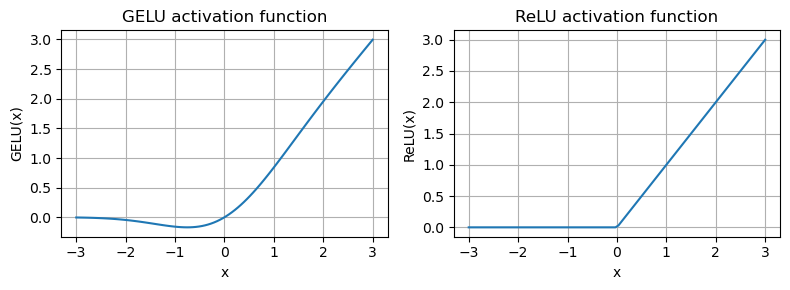

In [13]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# Some sample data
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()


#### Summarization of why GELU is used over ReLU

As we can see in the resulting plot, ReLU is a piecewise linear function that outputs the input directly if it is positive; otherwise, it outputs zero.

GELU is a smooth, nonlinear function that approximates ReLU but with a non-zero gradient for negative values.

The smoothness of GELU, as shown in the above figure, can lead to better optimization properties during training, as it allows for more nuanced adjustments to the model's parameters.

In contrast, ReLU has a sharp corner at zero, which can sometimes make optimization harder, especially in networks that are very deep or have complex architectures. Additionally, the ReLU activation function is non-differentiable at x=0

Moreover, unlike RELU, which outputs zero for any negative input, GELU allows for a small, non-zero output for negative values.

This characteristic means that during the training process, neurons that receive negative input can still contribute to the learning process, albeit to a lesser extent than positive inputs.

Now, we'll use the GELU function to implement the small NN module, FeedForward, that will be used in the LLM's transformer block later

In [14]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # Define multiple layers and create a NN through these layers
        # Layers are processed sequentially
        # Start with the first linear layer that expands the embedding dimension
        # Then apply GELU activation
        # Finally, reduce the dimension back to the original embedding size
        self.layers = nn.Sequential(
            nn.Linear(cfg['emb_dim'], 4 * cfg['emb_dim']), # Expansion
            GELU(), # Activation
            nn.Linear(4 * cfg['emb_dim'], cfg['emb_dim']), # Contraction
        )
    def forward(self, x):
        return self.layers(x)

In [15]:
print(GPT_CONFIG_124M['emb_dim'])

768


As we can see in the preceding code, the FeedForward module is a small neural network consisting of two Linear layers and a GELU activation function.

In the 124 million parameter GPT model, it receives the input batches with tokens that have an embedding size of 768 each via the GPT_CONFIG_124M dictionary where GPT_CONFIG_124M["emb_dim"] = 768.

Now, lets use the GELU function to implement the small NN module, FeedForward that we will be using in the LLM's transformer block later

In [16]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768) #A
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


The FeedForward module we implemented in this section plays a crucial role in enhancing the model's ability to learn from and generalize the data.

Although the input and output dimensions of this module are the same, it internally expands the embedding dimension into a higher-dimensional space through the first linear layer.

This expansion is followed by a non-linear GELU activation, and then a contraction back to the original dimension with the second linear transformation.

Such a design allows for the exploration of a richer representation space.

Moreover, the uniformity in input and output dimensions simplifies the architecture by enabling the stacking of multiple layers, as we will do later, without the need to adjust dimensions between them, thus making the model more scalable.

### GPT Architecture Part 4: Shortcut Connections

Below, we will be adding shortcut conncetions to the forward method

In [17]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        # Implementation goes here
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU()),
        ])
    
    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

The code implements a deep neural network with 5 layers, each consisting of a Linear layer and a GELU activation function.

In the forward pass, we iteratively pass the input through the layers and optionally add the shortcut connections if the self.use_shortcut attribute is set to True.

Now let's use this code to first initialize a neural network w/out shortcut connections. Here, each layer will be intialized such that it accepts an example with 3 input values and returns 3 output values. Last layer returns a signle output value.

In [18]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123) # specify random seed for the initial weights for reproducibility
model_without_shortcut = ExampleDeepNeuralNetwork(
layer_sizes, use_shortcut=False
)

Now, implement a function that computes the gradients in the model's backward pass:

In [19]:
def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])  # Dummy target for loss computation

    # Calculate loss based on how close the target and output are
    loss = nn.MSELoss()(output, target)

    # Backward pass to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient value for each weight parameter
            print(f"Mean absolute gradient for {name}: {param.grad.abs().mean().item()}")
        
    

In the code above, specify a loss function that computes how close the model output and a user-specified target (here, for simplicity, the value 0) are.

Then, when calling loss.backward(), PyTorch computes the loss gradient for each layer in the model.

We can iterate through the weight parameters via model.named_parameters().

Suppose we have a 3×3 weight parameter matrix for a given layer.

In that case, this layer will have 3×3 gradient values, and we print the mean absolute gradient of these 3×3 gradient values to obtain a single gradient value per layer to compare the gradients between layers more easily.

In short, the .backward() method is a convenient method in PyTorch that computes loss gradients, which are required during model training, without implementing the math for the gradient calculation ourselves, thereby making working with deep neural networks much more accessible.

Now, let's use the print_gradients function and apply it to the model without skip connections.

In [20]:
print_gradients(model_without_shortcut, sample_input)

Mean absolute gradient for layers.0.0.weight: 0.00020173587836325169
Mean absolute gradient for layers.1.0.weight: 0.0001201116101583466
Mean absolute gradient for layers.2.0.weight: 0.0007152041071094573
Mean absolute gradient for layers.3.0.weight: 0.0013988735154271126
Mean absolute gradient for layers.4.0.weight: 0.005049645435065031


As we can see based on the output of the print_gradients function, the gradients become smaller as we progress from the last layer (layers.4) to the first layer (layers.0), which is a phenomenon called the vanishing gradient problem.

Now, let's instantiate a model with shortcut connections and observe the gradients again.

In [21]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)


Mean absolute gradient for layers.0.0.weight: 0.22169791162014008
Mean absolute gradient for layers.1.0.weight: 0.20694106817245483
Mean absolute gradient for layers.2.0.weight: 0.32896995544433594
Mean absolute gradient for layers.3.0.weight: 0.2665732204914093
Mean absolute gradient for layers.4.0.weight: 1.3258540630340576


As we can see, based on the output, the last layer (layers.4) still has a larger gradient than the other layers.

However, the gradient value stabilizes as we progress towards the first layer (layers.0) and doesn't shrink to a vanishingly small value.

In conclusion, shortcut connections are important for overcoming the limitations posed by the vanishing gradient problem in deep neural networks.

Shortcut connections are a core building block of very large models such as LLMs, and they will help facilitate more effective training by ensuring consistent gradient flow across layers when we train the GPT model

### GPT ARCHITECTURE PART 5: CODING ATTENTION AND LINEAR LAYERS IN A TRANSFORMER BLOCK

In [22]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,      # Vocabulary size for GPT-2
    "context_length": 1024,   # Context length for GPT-2
    "emb_dim": 768,           # Embedding dimension for GPT-2
    "n_heads": 12,            # Number of attention heads for GPT-2
    "n_layers": 12,           # Number of transformer layers for GPT-2
    "drop_rate": 0.1,         # Dropout rate
    "qkv_bias": False,        # Query-Key-Value bias
}

#### THE BUILDING BLOCKS: Layer Normalization, GELL Activation, Feed-Forward Network

In [23]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        # Below are trainable parameters
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self, x):
        # Along last dim are embedding dimensions
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * x_norm + self.shift
    
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0  / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # Define multiple layers and create a NN through these layers
        # Layers are processed sequentially
        # Start with the first linear layer that expands the embedding dimension
        # Then apply GELU activation
        # Finally, reduce the dimension back to the original embedding size
        self.layers = nn.Sequential(
            nn.Linear(cfg['emb_dim'], 4 * cfg['emb_dim']), # Expansion
            GELU(), # Activation
            nn.Linear(4 * cfg['emb_dim'], cfg['emb_dim']), # Contraction
        )
    def forward(self, x):
        return self.layers(x)

In [24]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

In [25]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias = False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reudce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out) # New Linear layer to combine the head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )
    
    def forward(self, x):
        b, num_tokens, d_in = x.shape

        # Linear projections
        queries = self.W_query(x)  # (b, num_tokens, d_out)
        keys = self.W_key(x)       # (b, num_tokens, d_out)
        values = self.W_value(x)   # (b, num_tokens, d_out)

        # Reshape for multi-head attention
        # Implicitly split the matrix by adding a 'num_hdeas' dimension
        # Unroll last dim: (b,num_tokens,d_out) -> (b,num_tokens,num_heads,head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        queries = queries.transpose(1, 2) # Transpose by 1,2 b/c python has 0-indexing. We want to swap the token dimension with the num_heads dimension
        keys = keys.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2,3) # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens] # In case we are looking at a batch where num_tokens < context_length, we truncate the mask to the number of tokens

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        # dim = -1 because we want to make sure that all columns of a row sum up to 1
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        # (1,2) transpose corresponds to swapping num_tokens and num_heads back into place
        # Where we have the d_out corresponding to (num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1,2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out) # Make sure that when we reshape matrices, they are in the same block of memory, had we not done this, it becomes difficult to reshape.
        context_vec = self.out_proj(context_vec) # New optional projection, not strictly necessary

        return context_vec

In [26]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        # 2 * 4 * 768 size after this line
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

The given code defines a TransformerBlock class in PyTorch that includes a multi-head attention mechanism (MultiHeadAttention) and a feed forward network (FeedForward), both configured based on a provided configuration dictionary (cfg), such as GPT_CONFIG_124M

Layer normalization (LayerNorm) is applied before each of these two components, and dropout is applied after them to regularize the model and prevent overfitting.

This is also known as Pre-LayerNorm.

Older architectures, such as the original transformer model, applied layer normalization after the self-attention and feed-forward networks instead, known as Post-LayerNorm, which often leads to worse training dynamics.

The class also implements the forward pass, where each component is followed by a shortcut connection that adds the input of the block to its output. This critical feature helps gradients flow through the network during training and improves the learning of deep models

Using the GPT_CONFIG_124M dictionary we defined earlier, let's instantiate a transformer block and feed it some sample data
Create sample input of shape [batch_size, num_tokens, emb_dim]

In [27]:
torch.manual_seed(123) # specify random seed for the initial weights for reproducibility
x = torch.rand(2,4,768) # A
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)
print(f'Input shape: {x.shape}, \nOutput shape: {output.shape}')

Input shape: torch.Size([2, 4, 768]), 
Output shape: torch.Size([2, 4, 768])


We can see that from the code output, the transformer blokc maintains the input dimensions in its output. This shows that the transformer architecture is designed to preserve the shape of the data as it passes through each block, which is crucial for stacking multiple transformer blocks in deep learning models like GPT.

This design enables its effective application across a wide range of sequence-to-sequence tasks, where each output vector directly corresponds to an input vector, maintaining a one-to-one relationship.

However, the output is a context vector that combines information from all tokens in the sequence, not just the token at the current position.

This means that while the physical dimensions of the sequence (length and feature size) remain unchanged as it passes through the transformer block, the context of each output vector is re-encoded to integrate contextual information from across the entire input sequence

### GPT ARCHITECTURE PART 6: ENTIRE GPT MODEL ARCHITECTURE IMPLEMENTATION

In [28]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,      # Vocabulary size for GPT-2
    "context_length": 1024,   # Context length for GPT-2
    "emb_dim": 768,           # Embedding dimension for GPT-2
    "n_heads": 12,            # Number of attention heads for GPT-2
    "n_layers": 12,           # Number of transformer layers for GPT-2
    "drop_rate": 0.1,         # Dropout rate
    "qkv_bias": False,        # Query-Key-Value bias
}

The device setting will allow us to train the model on a CPU or GPU, depending on which device the input data sits

In [29]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

The init constructor of this GPTModel class initializes the token and positional embedding layers using the configurations passed in via a Python dictionary, cfg.

These embedding layers are responsible for converting input token indices into dense vectors and adding positional information.

Next, in init, a stack of TransformerBlock modules is created with depth set by cfg. The stack is followed by a LayerNorm to stabilize and standardize the block outputs, and a bias-free linear head that projects the transformer's final representations into the tokenizer's vocabulary space to produce logits.

The forward method accepts a batch of token indices, computes token embeddings, adds positional embeddings, runs the sequence through the transformer blocks, applies LayerNorm to the final hidden states, and produces vocabulary logits. Token/text conversion from those logits is handled in the next section.

Let's now initialize the 124 million parameter GPT model using the GPT_CONFIG_124M dictionary that was passed into the cfg parameter and feed it with the batch text input that was created at the beginning of this chapter:

In [30]:
# Batch code from earlier in the chapter
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)  # Shape: (2, seq_len)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [31]:
torch.manual_seed(123) # specify random seed for the initial weights for reproducibility
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)
print(f'Input batch: \n {batch}\n')
print(f'Output logits shape: {out.shape}\n')
print(out)

Input batch: 
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output logits shape: torch.Size([2, 4, 50257])

tensor([[[ 0.3613,  0.4223, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


As we can see, the output tensor has the shape [2, 4, 50257], since we passed in 2 input texts with 4 tokens each. The last dimension, 50,257, corresponds to the vocabulary size of the tokenizer. 

Next, we will see how we can convert each of those 50,257-dimensional vectors back into tokens

Using the numel() method, short for "number of elements," we can collect the total number of parameters in the model's parameter tensors:

In [32]:
total_params = sum(p.numel() for p in model.parameters())
print(f'Total number of parameters: {total_params:,}')

Total number of parameters: 163,009,536


Earlier, it was mentioned that we would be initializing a 124 million parameter GPT model, so why is the actual number of parameters 163 million, as shown in the preceding code output?

GPT-2 uses weight tying, so the output projection shares the token embedding matrix. To see this, compare the shapes of the token embedding and the linear output layer created earlier in the GPTModel.

In [33]:
print(f'Total embedding layer shape: {model.tok_emb.weight.shape}')
print(f'Output layer shape: {model.out_head.weight.shape}')

Total embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


As shown above, the weight tensors for both these layers have the same shape (50257, 768)

The token embedding and output layers are very large due to the number of rows for the 50,257 in the tokenizer's vocabulary. Let's remove the output layer parameter count from the total GPT-2 model count according to the weight tying:

In [34]:
total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f'Total number of trainable parameters in GPT-2 model, when considering weight tying: \n{total_params_gpt2:,}')

Total number of trainable parameters in GPT-2 model, when considering weight tying: 
124,412,160


As shown above, the model now only has 124 million parameters, which matches the original size of the GPT-2 model

Weight tying reduces the overall memory footprint and computational complexity of the model. However, using separate token embedding and output layers results in better training and model performance, which is why we are using separate layers in our GPTModel implementation. The same is true for modern LLMs.

Finally, lets compute the memory requirments of the 163 million parameters in the GPTModel object:

In [35]:
total_size_bytes = total_params * 4  # 4 bytes for float32
total_size_mb = total_size_bytes / (1024 ** 2)
print(f'Total size of the model (without weight tying): {total_size_mb:.2f} MB')

Total size of the model (without weight tying): 621.83 MB


By calculating the memory requirements for the 163 million parameters in the GPTModel object and assuming each parameter is a 32-bit float taking up 4 bytes, we can find that the total size of the model amounts to ~622 MB, which goes to show the relatively large storage capacity required to accommodate even relatively small LLMs

In this past section, we have implemented the GPTModel architecture and saw that it outputs numeric tensors of shape [batch_size, num_tokens, vocab_size].

Next, write the code that converts these output tensors into text



### GPT ARCHITECTURE PART 7: GENERATING TEXT FROM OUTPUT TOKENS

Steps for implementing the token-generation process:

Step 1: idx is a (batch, n_tokens) array of indices in the current context

Step 2: Crop current context if it exceeds the supported context size E.g., if LLM supports only 5 tokens, and the context size is 10 then only the last 5 tokens are used as context

Step 3: Focus only on the last time step, so that (batch, n_token, vocab_size) becomes (batch, vocab_size)

Step 4: probas has shape (batch, vocab_size)

Step 5: idx_next has shape (batch, 1)

Step 6: Append sampled index to the running sequence, where idx has shape (batch, n_tokens+1

In [36]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the currnet context

    ### Input batch: 
    ### tensor([[6109, 3626, 6100,  345],
    ###    [6109, 1110, 6622,  257]])

    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # i.e. If LLM supports only 5 tokens, and the context size is 10,
        # then only the last 5 tokens are used as context
        idx_cond = idx[:,-context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)  # (batch, n_tokens, vocab_size)
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) -> (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probs = torch.softmax(logits, dim=-1)  # (batch, vocab_size

        # Get the idx of the vocab entry with the highest probability value
        next_idx = torch.argmax(probs, dim=-1, keepdim=True)  # (batch, 1)

        # Append the predicted index to the running sequence
        idx = torch.cat((idx, next_idx), dim=-1)  # (batch, n_tokens+1)

    return idx

In generate_text_simple the logits are converted to probabilities with softmax and then torch.argmax is used to pick the highest entry. 

Because softmax is monotonic, it preserves the ordering of logits, so the index of the largest probability is the same as the index of the largest logit. 

Therefore applying argmax directly to the logits yields the same result and makes the softmax step unnecessary. 

The softmax call is retained here purely to demonstrate the full logits-to-probabilities workflow and to illustrate greedy decoding, which selects the most likely next token.

In the next part, when we implement the GPT training code, we will also introduce additional sampling techniques where we modiy the softmax outputs such that the model doesn't always select the most likely token, which introduces variability and creativity in the generated text (Temperature).

Below, we will try out the function to generate text, with the context as "Hello, I am" as the model input

First, we have to encode the input context into token IDs

In [37]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print(f'Encoded input context: {encoded}')
encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # Shape: (1, n_tokens)
print(f'Encoded input context tensor shape: {encoded_tensor.shape}')

Encoded input context: [15496, 11, 314, 716]
Encoded input context tensor shape: torch.Size([1, 4])


Next, put the model into .eval() mode, which will disable random componenets like dropout, which are only used during training, and then we can use the generate_text_simple function to generate new text based on the encoded input tensor

In [38]:
model.eval() # A
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"],
)
print(f'Output: {out}')
print(f'Output length: {len(out[0])}')


Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


Next, using decode method of the tokenizer, we can convert the output token IDs back into text

In [39]:
decoded_text = tokenizer.decode(out[0].tolist())
print(f'Decoded generated text: \n{decoded_text}')

Decoded generated text: 
Hello, I am Featureiman Byeswickattribute argue


Well, we can see that based on the preceeding output, the model generated gibberish which is not coherent text at all

This is because we have not trained the model yet, so its weights are still random.

So far, we have just implemented the GPT architecture and intialized as a GPT model instance with random weights, training will happen in the coming sections.

### Evaluating Generative Text Models

#### GPT Model Class:

In [40]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [41]:
import torch

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference

Reduce the context length (context_length) of only 256 tokens to reduce the computational resource requirements for training the model, whereas the original 124 million parameter GPT-2 model used 1024 tokens

I am not using a GPU, or a computer with good enough compute and memory, which is why I reduced the context length


Next, use the generate_text_simple function from the previous chapter to generate text.

In addition, define two convenience functions, text_to_token_ids and token_ids_to_text, for converting between token and text representations that we use throughout this chapter

In [42]:
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=20,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren Mortgage TT remember gard ACTIONSussedOND Land Engeledded


As we can see above, model does not produce good text because it hasn't been trained yet. 

How can we measure what 'good text' looks like, in a numeric form, to track it during training?

We can introduce metrics to calculate a loss metric for the generated outputs that we can use to measure the training progress
    
Next bits on finetuning LLMs will also introduce additional ways to measure model quality

#### Calculating the text generation loss: cross-entropy and perplexity

Suppose there is an inputs tensor containing the token IDs for 2 training examples (rows)

Corresponding to the inputs, the targets contain the desired token IDs that we want the model to generate

Notice that the targets are the inputs shifted by 1 position.

In [43]:
# From Pretraining LLMs: Loss Function Notes

inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

Feeding the inputs to the model, we get the logits vector for the 2 input examples that consist of 3 tokens each

Each of the tokens is a 50,257-dimensional vector corresponding to the size of the vocabulary

Applying the softmax function, we can turn the logits tensor into a tensor of the same dimension containing probability scores for next token generation

In [44]:
with torch.no_grad():
    logits = model(inputs)

probs = torch.softmax(logits, dim=-1) # Probability of each token in vocabulary
print(probs.shape) # Shape: (batch_size, num_tokens, vocab_size)


torch.Size([2, 3, 50257])


As discussed in the previous chapter, we can apply the argmax function to convert the probability scores into predicted token IDs.

The softmax function above produced a 50,257-dimensional vector for each token; the argmax function returns the position of the highest probability score in this vector, which is the predicted token ID for the given token.

Since we have 2 input batches with 3 tokens each, we obtain 2 by 3 predicted token IDs:

In [45]:
token_ids = torch.argmax(probs, dim=-1, keepdims=True)
print(f'Token IDs: \n{token_ids}')

Token IDs: 
tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


If we decode these tokens, we find that these are quite different from the tokens we want the model to predict, namely the target tokens.

That's because the model wasn't trained yet.

To train the model, we need to know how far it is away from the correct predictions (targets).

We need an effective loss function

In [46]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


#### Cross-entropy Loss

Token probabilities corresponding to the target indices are as follows:

In [47]:
# text_idx represents what batch we are looking at 0-indexed.
text_idx = 0
target_probs_1 = probs[text_idx, [0,1,2], targets[text_idx]]
print(f'Text 1: {target_probs_1}')

text_idx = 1
target_probs_2 = probs[text_idx, [0,1,2], targets[text_idx]]
print(f'Text 2: {target_probs_2}')

Text 1: tensor([    0.0001,     0.0000,     0.0000])
Text 2: tensor([    0.0000,     0.0001,     0.0000])


We want to maximize all these values, bringing them close to a probability of 1.

In mathematical optimization, it is easier to maximize the logarithm of the probability score than the probability score itself.

In [48]:
# Compute logarithm of all target probabilities
log_probs = torch.log(torch.cat((target_probs_1, target_probs_2)))
print("Log probabilities:\n ", log_probs)

Log probabilities:
  tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


Next, compute the average log probability

In [49]:
# Calculate average log probability for each token
avg_log_probs = torch.mean(log_probs)
print("Average Log Probabilities: \n", avg_log_probs)

Average Log Probabilities: 
 tensor(-10.7940)


The goal is to make this average log probability as large as possible by optimizing the model weights.

Due to the log, the largest possible value is 0, and we are currently far away from 0.

In deep learning, instead of maximizing the average log-probability, it's a standard convention to minimize the negative average log-probability value; in our case, instead of maximizing -10.7722 so that it approaches 0, in deep learning, we would minimize 10.7722 so that it approaches 0.

The value negative of -10.7722, i.e., 10.7722, is also called cross-entropy loss in deep learning.

In [50]:
neg_avg_log_probs = avg_log_probs * -1
print("Cross Entropy Loss: \n", neg_avg_log_probs)

Cross Entropy Loss: 
 tensor(10.7940)


PyTorch already implements a cross_entropy function that carries out the previous steps

Before we apply the cross_entropy function, let's check the shape of the logits and targets

In [51]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch_size, num_tokens)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


For the cross_entropy function in PyTorch, we want to flatten these tensors by combining them over the batch dimension:

Essentially, stack the batches over each other, s.t. dimensions become (input_tokens_stacked, vocab_size) for logits, and (input_tokens_stacked) for targets

In [52]:
logits_flat = logits.flatten(0,1)
targets_flat = targets.flatten()

print("Flattened logits: \n", logits_flat.shape)
print("Flattened targets: \n", targets_flat.shape)

Flattened logits: 
 torch.Size([6, 50257])
Flattened targets: 
 torch.Size([6])


Note that the targets are the token IDs, which also represent the index positions in the logits tensors that we want to maximize.

The cross_entropy function in PyTorch will automatically take care of applying the softmax and log-probability computation internally over those token indices in the logits that are to be maximized

In [53]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print("Cross Entropy Loss: \n", loss)

Cross Entropy Loss: 
 tensor(10.7940)


#### Perplexity

A concept related to the cross-entropy loss is the perplexity of an LLM.

The perplexity is simply the exponential of the cross-entropy loss.

In [54]:
perplexity = torch.exp(loss)
print("Perplexity: \n", perplexity)

Perplexity: 
 tensor(48725.8203)


The perplexity is often considered more interpretable because it can be understood as the effective vocabulary size that the model is uncertain about at each step (in the example above, that'd be 48,725 words or tokens).

The model we have is roughly as uncertain as if it had to choose the next token randomly, from about 48,725 tokens in the vocabulary. Note that are vocabulary size is 50,257, so the model terrible right now

In other words, perplexity provides a measure of how well the probability distribution predicted by the model matches the actual distribution of the words in the dataset.

Similar to the loss, a lower perplexity indicates that the model predictions are closer to the actual distribution

#### Calculating the training and validation set losses

We use a relatively small dataset for training the LLM (in fact, only one short story)

The reasons are:

You can run the code examples in a few minutes on a laptop computer without a suitable GPU.

The training finishes relatively fast (minutes instead of weeks), which is good for educational purposes.

We use a text from the public domain, which can be included in this GitHub repository without violating any usage rights or bloating the repository size.

For example, Llama 2 7B required 184,320 GPU hours on A100 GPUs to be trained on 2 trillion tokens

At the time of this writing, the hourly cost of an 8xA100 cloud server at AWS is approximately 30 dollars.

So, via an off-the-envelope calculation, training this LLM would cost 184,320 / 8 * 30 = 690,000 dollars

Below, we use the same dataset we used in chapter 2.

In [96]:
# ...existing code...
import os
import urllib.request

file_path = '../books_text/the-verdict.txt'
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

def ensure_text(path, url, min_size=100):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    if (not os.path.exists(path)) or os.path.getsize(path) < min_size:
        with urllib.request.urlopen(url) as resp:
            text = resp.read().decode('utf-8')
        with open(path, 'w', encoding='utf-8') as f:
            f.write(text)
    with open(path, 'r', encoding='utf-8') as f:
        return f.read()

text_data = ensure_text(file_path, url)

In [56]:
# set HP file path (fix spelling if needed)
hp_file_path = '../books_text/sorcerers-stone.txt' 
if not os.path.exists(hp_file_path):
    raise FileNotFoundError(f'File not found: {hp_file_path}')
else:
    with open(hp_file_path, 'r', encoding='utf-8') as file:
        hp_text_data = file.read()

In [61]:
# First 100 characters to test if text was loaded correctly
print(text_data[:99] + '\n')
print(hp_text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 

THE BOY WHO LIVED

Mr. and Mrs. Dursley, of number four, Privet Drive,
were proud to say that they 


In [62]:
# Last 100 characters:
print(text_data[-99:])
print(hp_text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."
 we’re not allowed to use magic at home. I’m
going to have a lot of fun with Dudley this summer...”


In [125]:
import tiktoken

tokenizer = tiktoken.get_encoding('gpt2')

In [64]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print(f'Characters: {total_characters}')
print(f'Total tokens: {total_tokens}')

total_hp_characters = len(hp_text_data)
total_hp_tokens = len(tokenizer.encode(hp_text_data))

print(f'HP Characters: {total_hp_characters}')
print(f'HP Total tokens: {total_hp_tokens}')


Characters: 20479
Total tokens: 5145
HP Characters: 441832
HP Total tokens: 133860


With 5,145 tokens, the text is very short for training an LLM, but again, it's for educational purposes (we will also load pretrained weights later).

Next, we divide the dataset into a training and a validation set and use the data loaders from chapter 2 to prepare the batches for LLM training.

For visualization purposes, the figure below assumes a max_length=6, but for the training loader, we set the max_length equal to the context length that the LLM supports.

Since we train the LLM to predict the next word in the text, the targets look the same as these inputs, except that the targets are shifted by one position

### Implementing the DataLoader

In [65]:
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize entire text
        token_ids = tokenizer.encode(txt, allowed_special = {"<|endoftext|>"})

        # Use sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids)-max_length, stride):
            input_chunk = token_ids[i:i+max_length]
            target_chunk = token_ids[i+1:i+1+max_length]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))
    
    def __len__(self):
        return len(self.input_ids)

    # What DataLoader will be using
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]
    

def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):
    
    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle, 
        drop_last=drop_last, # If last batch size is very small, it just drops it (not equal to full batch size)
        num_workers=num_workers
    )
    return dataloader

In [77]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,      # Vocabulary size for GPT-2
    "context_length": 256,    # Shortened context length (original: 1024)
    "emb_dim": 768,           # Embedding dimension for GPT-2
    "n_heads": 12,            # Number of attention heads for GPT-2
    "n_layers": 12,           # Number of transformer layers for GPT-2
    "drop_rate": 0.1,         # Dropout rate
    "qkv_bias": False,        # Query-Key-Value bias
}

In [78]:
# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size = 2,
    max_length = GPT_CONFIG_124M['context_length'],
    stride = GPT_CONFIG_124M['context_length'],
    drop_last = True,
    shuffle = True,
    num_workers = 0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size = 2,
    max_length = GPT_CONFIG_124M['context_length'],
    stride = GPT_CONFIG_124M['context_length'],
    drop_last = True,
    shuffle = True,
    num_workers = 0
)

In [79]:
GPT_CONFIG_124M_HP = {
    "vocab_size": 50257,      # Vocabulary size for GPT-2
    "context_length": 1024,   # Set to 1024 for harry potter
    "emb_dim": 768,           # Embedding dimension for GPT-2
    "n_heads": 12,            # Number of attention heads for GPT-2
    "n_layers": 12,           # Number of transformer layers for GPT-2
    "drop_rate": 0.1,         # Dropout rate
    "qkv_bias": False,        # Query-Key-Value bias
}

In [83]:
# Train/validation ratio FOR HARRY POTTER
train_ratio_hp = 0.90
split_idx_hp = int(train_ratio_hp * len(hp_text_data))
train_data_hp = hp_text_data[:split_idx_hp]
val_data_hp = hp_text_data[split_idx_hp:]

torch.manual_seed(123)

train_loader_hp = create_dataloader_v1(
    train_data_hp,
    batch_size = 2,
    max_length = GPT_CONFIG_124M_HP['context_length'],
    stride = GPT_CONFIG_124M_HP['context_length'],
    drop_last = True,
    shuffle = True,
    num_workers = 0
)

val_loader_hp = create_dataloader_v1(
    val_data_hp,
    batch_size = 2,
    max_length = GPT_CONFIG_124M_HP['context_length'],
    stride = GPT_CONFIG_124M_HP['context_length'],
    drop_last = True,
    shuffle = True,
    num_workers = 0
)

In [84]:
# Sanity check

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

# Sanity check for HP
if total_hp_tokens * (train_ratio_hp) < GPT_CONFIG_124M_HP["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_hp_tokens * (1-train_ratio_hp) < GPT_CONFIG_124M_HP["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

We use a relatively small batch size to reduce the computational resource demand, and because the dataset is very small to begin with.

Llama 2 7B was trained with a batch size of 1024, for example.

Check that the data was loaded correctly:

In [85]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [86]:
print("Train loader Harry Potter:")
for x, y in train_loader_hp:
    print(x.shape, y.shape)

print("\nValidation loader Harry Potter:")
for x, y in val_loader_hp:
    print(x.shape, y.shape)

Train loader Harry Potter:
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch.Size([2, 1024]) torch.Size([2, 1024])
torch

In [88]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print(f'Training tokens: {train_tokens}')
print(f'Validation tokens: {val_tokens}')
print(f'All tokens: {train_tokens + val_tokens} \n')

train_tokens_hp = 0
for input_batch, target_batch in train_loader_hp:
    train_tokens_hp += input_batch.numel()

val_tokens_hp = 0
for input_batch, target_batch in val_loader_hp:
    val_tokens_hp += input_batch.numel()

print(f'Training tokens (HARRY POTTER): {train_tokens_hp}')
print(f'Validation tokens (HARRY POTTER): {val_tokens_hp}')
print(f'All tokens (HARRY POTTER): {train_tokens_hp + val_tokens_hp} \n \n')


Training tokens: 4608
Validation tokens: 512
All tokens: 5120 

Training tokens (HARRY POTTER): 118784
Validation tokens (HARRY POTTER): 12288
All tokens (HARRY POTTER): 131072 
 



### Here is the GPT Model class coded earlier. Will need this.

In [90]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval() # Disable dropout during inference

model_hp = GPTModel(GPT_CONFIG_124M_HP)
model.eval() # Disable dropout during inference


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

Next, implement a utility function to calculate the cross-entropy loss of a given batch

Also, implement a second utility function to compute the loss for a user-specified number of batches in a data loader

In [91]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    # First, applies softmax to logits tensor
    # Second, takes values in first argument corresponding to values in second argument
    # Third, flattens them so dimensions match up
    # Finally, gets the negative log likelihood
    loss = torch.nn.functional.cross_entropy(logits.flatten(0,1), target_batch.flatten())
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0
    if len(data_loader) == 0:
        return float('nan')
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss
        else:
            break
    return total_loss / num_batches


If you have a machine with a CUDA-supported GPU, the LLM will train on the GPU without making any changes to the code.

Via the device setting, we ensure that the data is loaded onto the same device as the LLM model.

### FOR The-Verdict TEXT:

In [93]:
device =  torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Note:
# Uncommenting the following lines will allow the code to run on Apple Silicon chips, if applicable,
# which is approximately 2x faster than on an Apple CPU (as measured on an M3 MacBook Air).
# However, the resulting loss values may be slightly different.

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using {device} device.")

model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet.
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print(f'Training loss: {train_loss}')
print(f'Validation loss: {val_loss}')

Using mps device.
Training loss: 10.98758316040039
Validation loss: 10.98110580444336


### FOR HARRY POTTER:

In [ ]:

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet.
    train_loss = calc_loss_loader(train_loader_hp, model_hp, device='cpu')
    val_loss = calc_loss_loader(val_loader_hp, model_hp, device='cpu')

print(f'Training loss: {train_loss}')
print(f'Validation loss: {val_loss}')

Training loss: 11.010736465454102
Validation loss: 11.001463890075684


### Training Loop for the LLM

In [ ]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad(): # Do not need to keep track of gradient updates and can even disable dropouts
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

The evaluate_model function above calculates the loss over the training and validation set while ensuring the model is in evaluation mode with gradient tracking and dropout disabled when calculating the loss over the training and validation sets

In [105]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

The generate_and_print_sample function is a convenience function that we use to track whether the model improves during the training.

In particular, the generate_and_print_sample function takes a text snippet (start_context) as input, converts it into token IDs, and feeds it to the LLM to generate a text sample using the generate_text_simple function we used earlier

In [106]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    
    # Initalize lists to track the losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0,-1

    # Main training loop
    for epoch in range(num_epochs):
        model.train() # Set model to training mode (for gradient updates)

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients (backward pass)
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel() # Returns the total number of elements (or tokens) in the input_batch.
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        
        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

#### STEPS OUTLINED ABOVE:
Step 1: Initialize lists to track losses and tokens seen

Step 2: Start the main training loop

Step 3: Reset loss gradients from previous batch iteration

Step 4: Calculate loss gradients

Step 5: Update model weights using loss gradients

Step 6: Optional evaluation step

Step 7: Print a sample text after each epoch

Time to test it by training a GPTModel instance for 10 epochs using an AdamW optimizer and the train_model_simple function defined earlier.

AdamW uses weight-decay. Leads to faster convergence and avoids local minima. (Subtracts a portion from large weights, great for regularization)

#### NOTE: This is for the-verdict.txt


In [125]:
# Note: Code below is used to calculate the execution time
import time
start_time = time.time()
####
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device, 
    num_epochs=num_epochs, eval_freq = 5, eval_iter = 5,
    start_context = "Every effort moves you", tokenizer=tokenizer
)

# Note: Code below shows execution time
end_time = time.time()
execution_time_in_mins = (end_time-start_time) / 60
print(f'Training completed in {execution_time_in_mins:.2f} minutes!')

Ep 1 (Step 000000): Train loss 9.939, Val loss 10.013
Ep 1 (Step 000005): Train loss 8.040, Val loss 8.420
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 2 (Step 000010): Train loss 6.607, Val loss 7.053
Ep 2 (Step 000015): Train loss 6.003, Val loss 6.595
Every effort moves you, the to the to the, the, the, the the, the, the, the to the, the, the the to the, the, the the the to the the to the to the the to the to the, the, the
Ep 3 (Step 000020): Train loss 16.216, Val loss 16.272
Ep 3 (Step 000025): Train loss 5.636, Val loss 6.461
Every effort moves you, and to the picture. I had been. I had. ". I had, and I had been. I had been. I had been, and his-- a, and his his--, and, and his, and I had been
Ep 4 (Step 000030): Train loss 5.060, Val loss 6.292
Ep 4 (Step 000035): Train loss 4.819, Val loss 6.299
Every effort moves you, and "I "I had to the picture. "I.  "I--and, I had to the of the picture. "I, I had the picture, I had the picture. "I I
Ep 5 (Step 

As we can see, based on the results printed during the training, the training loss improves drastically, starting with a value of 9.817 and converging to 0.605.

The language skills of the model have improved quite a lot. In the beginning, the model is only able to append commas to the start context ("Every effort moves you,,,,,,,,,,,,") or repeat the word "and".

At the end of the training, it can generate grammatically correct text, however we still have a massive overfitting issue

Similar to the training set loss, we can see that the validation loss starts high (9.924) and decreases during the training.

However, it never becomes as small as the training set loss and remains at 6.388 after the 10th epoch.

Below is a plot that shows the training and validation set losses side by side

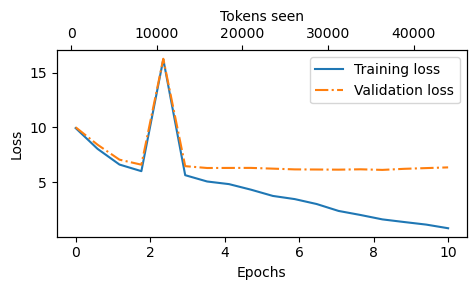

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.png")
    plt.show()

# make sure tensors are on CPU and converted to numpy
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
epochs_np = epochs_tensor.detach().cpu().numpy()

# tokens_seen may be a Python list or tensor; normalize to numpy
if isinstance(tokens_seen, torch.Tensor):
    tokens_np = tokens_seen.detach().cpu().numpy()
else:
    tokens_np = np.array([t.item() if torch.is_tensor(t) else t for t in tokens_seen])

# train_losses / val_losses may contain tensors -> convert to float arrays
train_np = np.array([t.item() if torch.is_tensor(t) else float(t) for t in train_losses])
val_np   = np.array([t.item() if torch.is_tensor(t) else float(t) for t in val_losses])

plot_losses(epochs_np, tokens_np, train_np, val_np)

Both the training and validation losses start to improve for the first epoch. However, the losses start to diverge past the second epoch.

Most notably, there seems to be a massive hitch around epoch 2 where the training and val loss jump to 16, but quickly fall back down in the next epoch

This divergence and the fact that the validation loss is much larger than the training loss indicate that the model is overfitting to the training data.

We can confirm that the model memorizes the training data verbatim by searching for the generated text snippets, such as "quite insensible to the irony" in the "The Verdict" text file.

This memorization is expected since we are working with a very, very small training dataset and training the model for multiple epochs.

Usually, it's common to train a model on a much, much larger dataset for only one epoch.

#### Lets try this on Harry Potter and the Sorcerers Stone


In [ ]:
start_time = time.time()
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M_HP)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
# Try one epoch at first
device = 'cpu'
num_epochs_hp = 10
train_losses_hp, val_losses_hp, tokens_seen_hp = train_model_simple(
    model_hp, train_loader_hp, val_loader_hp, optimizer, device, 
    num_epochs=num_epochs_hp, eval_freq = 5, eval_iter = 5,
    start_context = "The boy who lived", tokenizer=tokenizer
)
# Note: Code below shows execution time
end_time = time.time()
execution_time_in_mins = (end_time-start_time) / 60
print(f'Training completed in {execution_time_in_mins:.2f} minutes!')

Ep 1 (Step 000000): Train loss 11.014, Val loss 11.001
Ep 1 (Step 000005): Train loss 11.007, Val loss 11.000
Ep 1 (Step 000010): Train loss 11.005, Val loss 11.002
Ep 1 (Step 000015): Train loss 11.017, Val loss 11.004
Ep 1 (Step 000020): Train loss 11.017, Val loss 11.000
Ep 1 (Step 000025): Train loss 11.014, Val loss 11.008
Ep 1 (Step 000030): Train loss 11.018, Val loss 11.003
Ep 1 (Step 000035): Train loss 11.014, Val loss 11.000
Ep 1 (Step 000040): Train loss 11.001, Val loss 11.000
Ep 1 (Step 000045): Train loss 11.006, Val loss 10.998
Ep 1 (Step 000050): Train loss 11.010, Val loss 11.007
Ep 1 (Step 000055): Train loss 11.012, Val loss 11.004
The boy who lived Susan Sus compliments condosun"); dise automatically Ele Norm serv booth palate CPUClamaster losty Bowser357greSQLimir hashing signsRunarencow ratio keys Risingdoms nos HUGEPress atherespond=#TRY topped embry religious tart MaterialCore Survey focusing Panda plunvP Jail
Ep 2 (Step 000060): Train loss 10.997, Val loss 11.

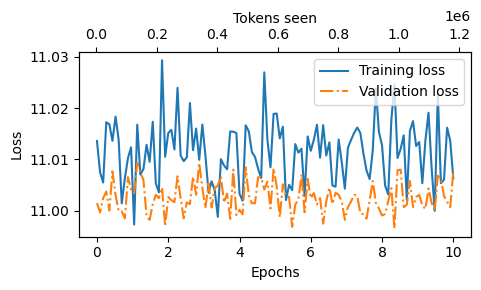

In [130]:
epochs_tensor_hp = torch.linspace(0, num_epochs_hp, len(train_losses_hp))
epochs_np_hp = epochs_tensor_hp.detach().cpu().numpy()

# tokens_seen may be a Python list or tensor; normalize to numpy
if isinstance(tokens_seen_hp, torch.Tensor):
    tokens_np_hp = tokens_seen_hp.detach().cpu().numpy()
else:
    tokens_np_hp = np.array([t.item() if torch.is_tensor(t) else t for t in tokens_seen_hp])

# train_losses / val_losses may contain tensors -> convert to float arrays
train_np_hp = np.array([t.item() if torch.is_tensor(t) else float(t) for t in train_losses_hp])
val_np_hp   = np.array([t.item() if torch.is_tensor(t) else float(t) for t in val_losses_hp])

plot_losses(epochs_np_hp, tokens_np_hp, train_np_hp, val_np_hp)